In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("intro2Matplotlib.ipynb")

So far, we've introduced basic Python syntax, how to load in and manipulate data, and we've begun introducing statistical libraries, methods, and functions.

Before we introduce the next two (possibly most important) statistical packages (`SciPy` & `statsmodels`), we are going to spend two lectures on visualization. We will cover `Matplotlib` first, then `seaborn`. These visualization packages will help us see our data and visualize the functions and methods we will cover in later lectures.

## Lecture Section

In this lecture, we will cover the `matplotlib` library.
Specifically:

* Plotting `plt`
    * Line Plots
    * Scatter Plots
    * Bar Plots & Histograms
    * Pie Charts
    * Figures vs. Axes vs. Plots
    * Saving Figures
    * 3D Plots


* Customizing Figures
    * Grids/Legends
    * Colors
    * Axes
    * Titles
    * Subplots
    * Layouts




### `plt`

To plot, we import `matplotlib.pyplot` under the alias `plt`. We then create two NumPy arrays - one holds the x-coordinates of our points, and the other holds the y-coordinates. Then, we pass these arrays to `plt.plot(x, y)`. To make the plot visible, we call `plt.show()`. This isn't required in a notebook, but you might see me do it out of habit, anyway.

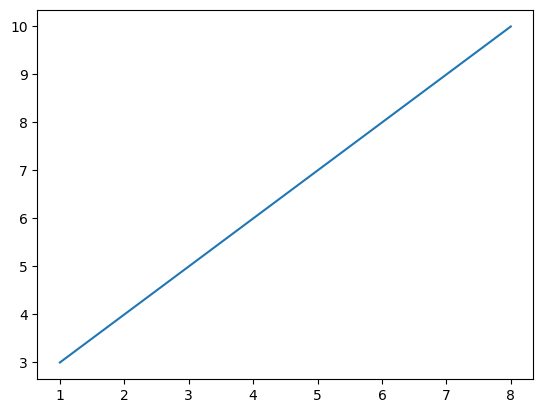

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpmath import linspace

x = np.array([1, 8])
y = np.array([3, 10])

plt.plot(x, y)
plt.show()


To create a scatter plot, we call `.scatter()` instead of `.plot()`.

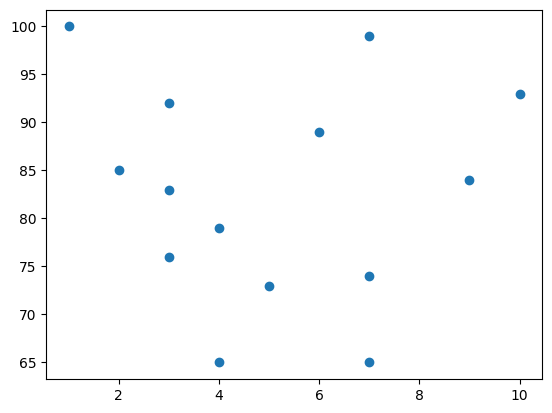

In [3]:
x = np.array([3, 7, 5, 4, 9, 2, 6, 1, 7, 10, 3, 3, 7, 4])
y = np.array([92, 65, 73, 79, 84, 85, 89, 100, 74, 93, 83, 76, 99, 65])
plt.scatter(x, y)
plt.show()

To create a bar plot, or a histogram...

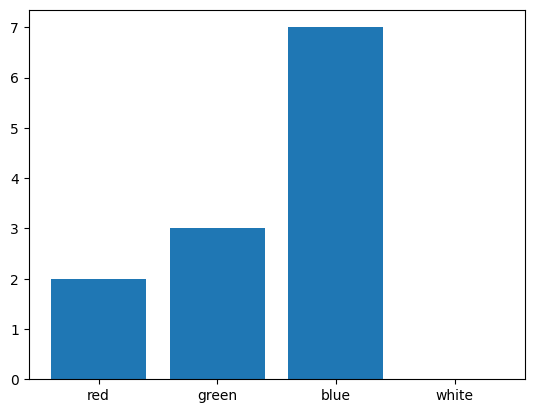

In [4]:
x = np.array(["red", "green", "blue", "white"])
y = np.array([2, 3, 7, 0])

plt.bar(x,y)
plt.show()

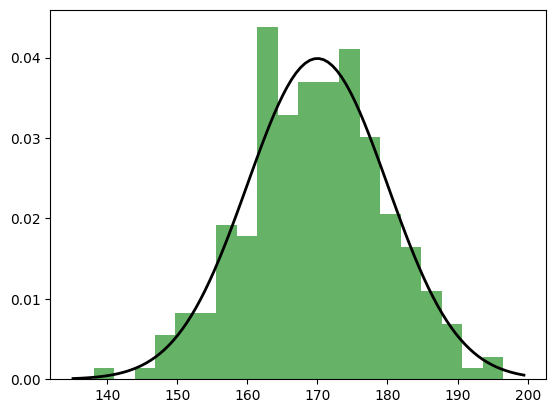

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm

x = np.random.normal(170, 10, 250)

plt.hist(x, bins=20, density=True, alpha=0.6, color='g')

# plot pdf/ fit a line to the curve of the histogram
xmin, xmax = plt.xlim()
x_range = np.linspace(xmin, xmax, 100)
plt.plot(x_range, norm.pdf(x_range, 170, 10), 'k', linewidth=2)



We can also create pie-charts/graphs

([<matplotlib.patches.Wedge at 0x788a9e8ca3c0>,
 [Text(0.4993895781431485, 0.9801071621215756, ''),
  Text(-1.0864572197158957, 0.17207762703851495, ''),
  Text(-0.17207745003216413, -1.0864572477508851, ''),
  Text(0.9801074062041268, -0.49938909910391416, '')])

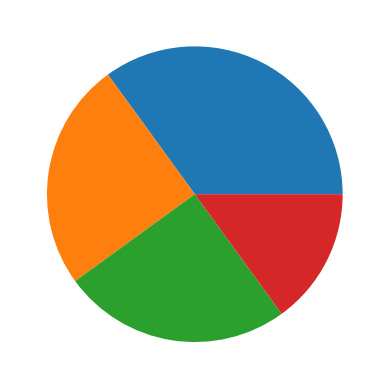

In [7]:
y = np.array([35, 25, 25, 15])

plt.pie(y)

**Notice that each new plot overwrites the one we created before it - we cannot get them back.**

This is expected. In a notebook like this, it is not much of a problem. There are three solutions if you want to access an earlier graph later.

1. Create a function that replots the points when called.
2. Save the plot and display it as an image.
3. Create subplots.

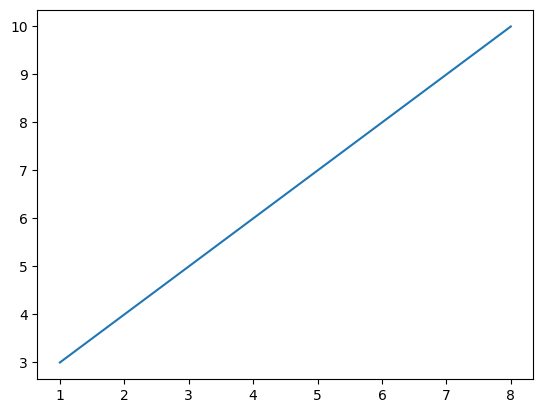

In [8]:
'''
1. Create a function that replots the points when called.
'''

def plot1():
    x = np.array([1, 8])
    y = np.array([3, 10])
    plt.plot(x, y)
    plt.show()

plot1()

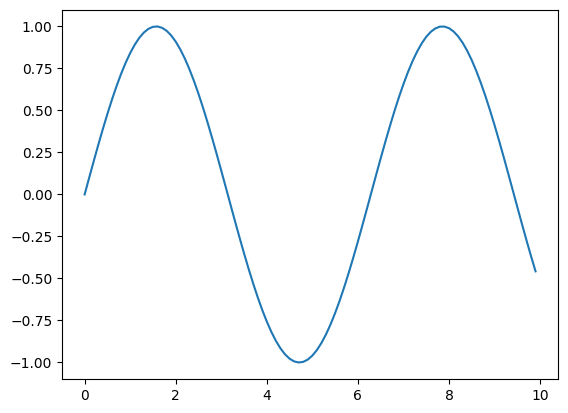

In [9]:
'''
2. Save the plot and display it as an image.
'''
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

x = np.arange(0, 10, 0.1)
y = np.sin(x)

plt.plot(x, y)
plt.savefig('saved_line.png')


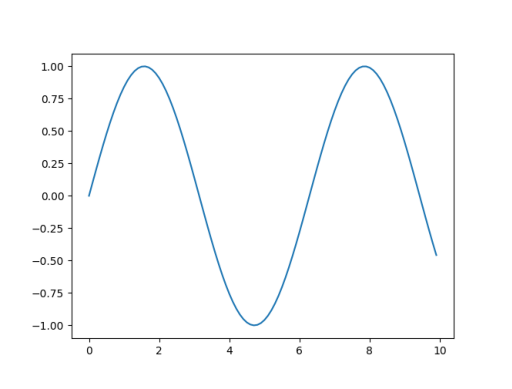

In [10]:
img = mpimg.imread('saved_line.png')

# Display the image
plt.imshow(img)
plt.axis('off')  # Hides the axis ticks and labels
plt.show()

Before we get to subplots... let's briefly talk about Figures.

Matplotlib is object-oriented (yes, the same kind we covered already!). The **figure** is the entire canvas, or background object of your plots. A **figure** holds **axes** (and labels, etc.), which can take the form of plots, scatter plots, histograms, etc. In the examples above, we have one **figure** and one **axes**. The **axes** above are either a `.plot()` or a `.scatter()`.

In the following three code blocks, all the examples result in the same thing. The `plt` interface in the first example is simply more convenient.

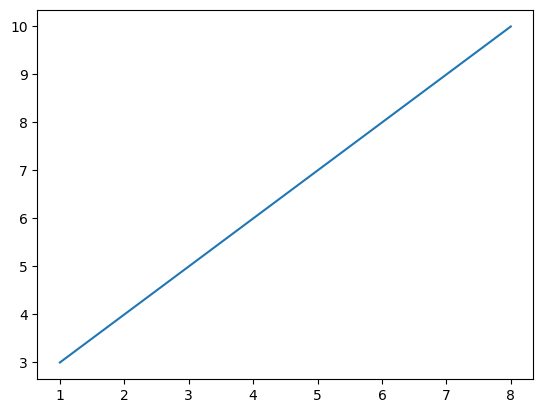

In [11]:
# plt interface
x = np.array([1, 8])
y = np.array([3, 10])
plt.plot(x, y)

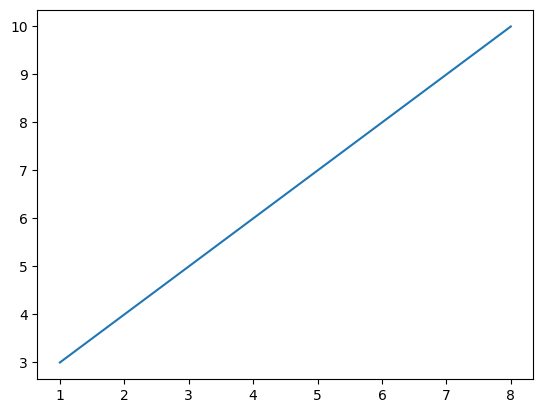

In [12]:
# axes form (more customization)
ax = plt.subplot()
ax.plot(x, y)

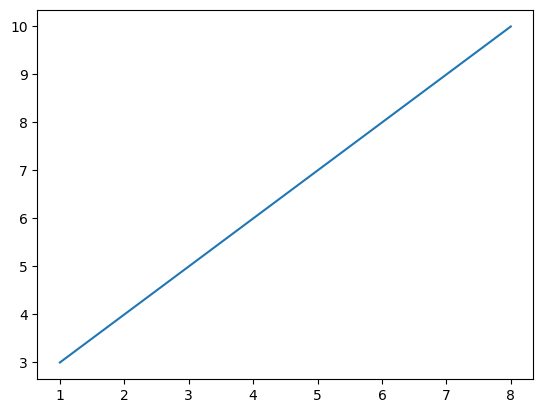

In [13]:
# breaking down to a figure
figure = plt.figure()
new_axes = figure.add_subplot()
new_axes.plot(x, y)

If a figure can hold multiple axes, then we can create multiple plots (or subplots).

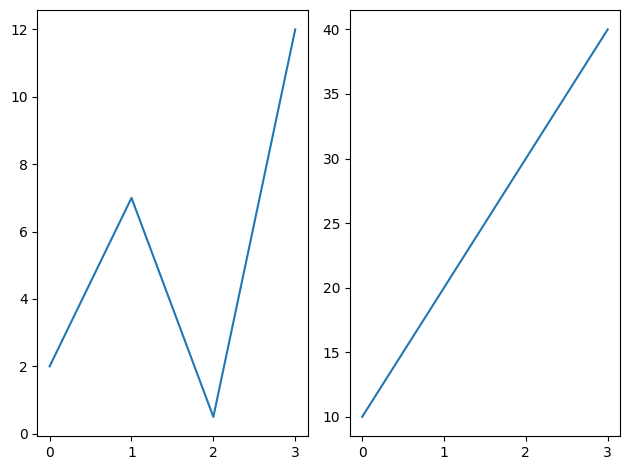

In [14]:
'''
3. Create subplots.
'''
fig, (ax1, ax2) = plt.subplots(1, 2)
x = np.array([0, 1, 2, 3])
y = np.array([2, 7, 0.5, 12])

ax1.plot(x,y)

x = np.array([0, 1, 2, 3])
y = np.array([10, 20, 30, 40])

ax2.plot(x,y)

plt.tight_layout() # stops overlapping


To get two separate figures that we can change and view at later times, we simply number our current figure before plotting.

Due to the type of back-end matplotlib operates on with Jupyter, we need to use `dsiplay()` from `IPython.display`. In Python scripts, we could call `fig0.show()`, but you'll likely get an error with this in Jupyter.

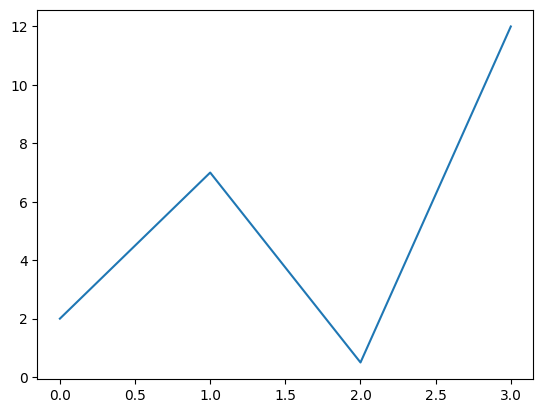

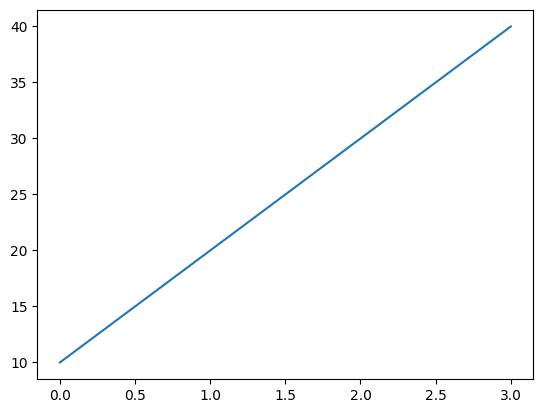

In [15]:
x = np.array([0, 1, 2, 3])
y = np.array([2, 7, 0.5, 12])
fig0 = plt.figure(0)
plt.plot(x, y)

x = np.array([0, 1, 2, 3])
y = np.array([10, 20, 30, 40])
fig1 = plt.figure(1)
plt.plot(x, y)

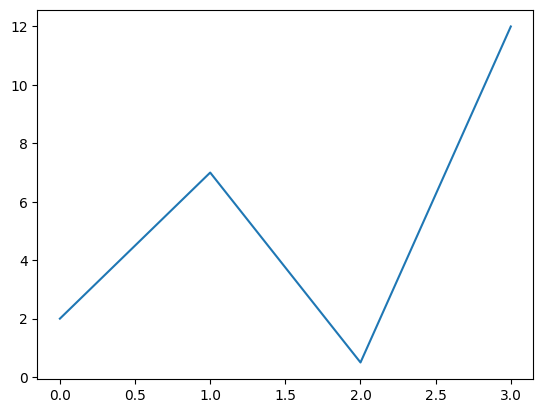

In [16]:
from IPython.display import display

display(fig0)

Now that we know about **figures** and **axes**, we can create a 3D graph.

Again, Jupyter's matplotlib uses a non-interactable backend. If you were to run this code in a regular Python script, you would be able to interact with the 3D graph.

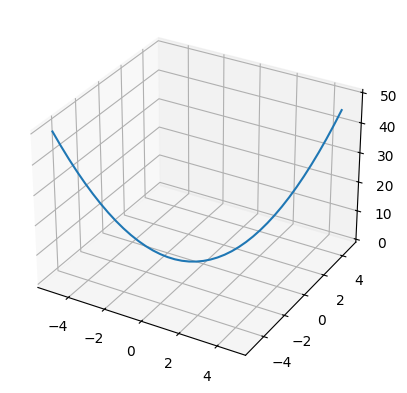

In [17]:
fig = plt.figure()
ax = plt.axes(projection = '3d')
x = np.arange(-5, 5, 0.25)
y = np.arange(-5, 5, 0.25)
z = x**2 + y**2
plt.plot(x, y, z)
plt.show()

### Customization

Matplotlib is highly customizable.

For example, we can change the **marker** of our datapoints.

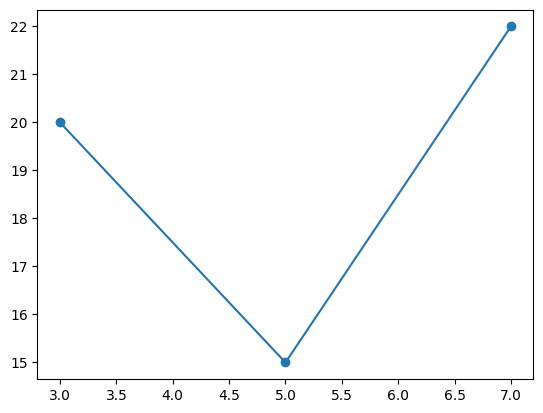

In [18]:
x = np.array([3, 5, 7])
y = np.array([20, 15, 22])
plt.plot(x, y, marker='o')

We can change the line style, and the color, too.

The shorthand notation options can be found here: https://www.w3schools.com/python/matplotlib_markers.asp

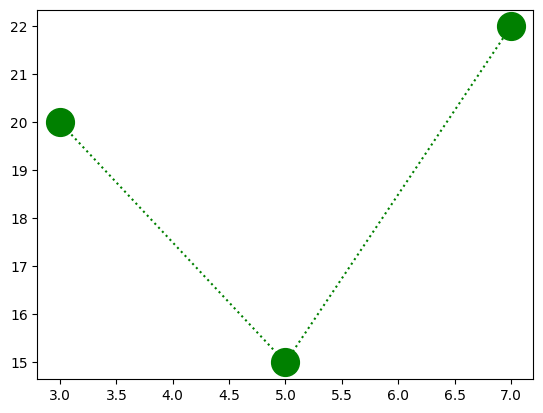

In [19]:
x = np.array([3, 5, 7])
y = np.array([20, 15, 22])
plt.plot(x, y, 'o:g', ms=20) # ms changes the size of the marker!

There are tons of other options. Here are a few selected options:
* linewidth: '20.5' - changes the width of the line
* mfc: 'b' - changes the color of the marker
* c: 'hotpink' - changes the color of the line
* ls: 'dotted' - changes the style of the line

We are also able to plot multiple lines on the same graph, and we can show a grid in the background.

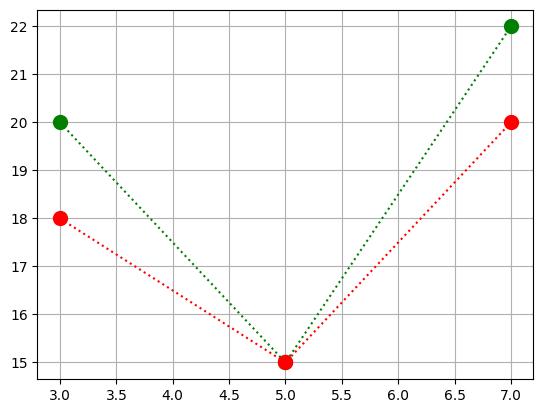

In [20]:
x = np.array([3, 5, 7])
y = np.array([20, 15, 22])
y2 = np.array([18, 15, 20])
plt.plot(x, y, 'o:g', ms=10) # ms changes the size of the marker!
plt.plot(x, y2, 'o:r', ms=10)
plt.grid()

We can add labels to the x and y axis, and a title to the overall graph.

Text(0.5, 1.0, 'Example Graph')

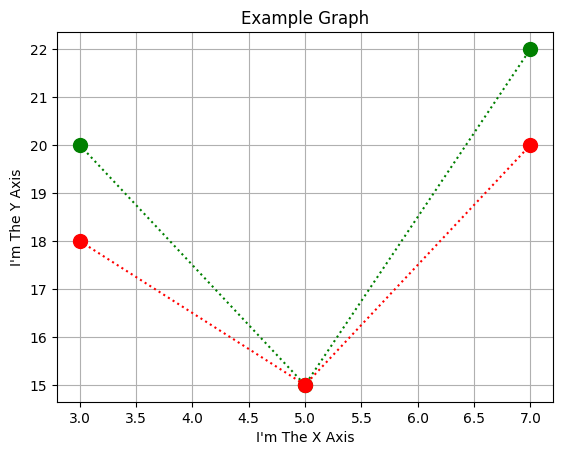

In [21]:
x = np.array([3, 5, 7])
y = np.array([20, 15, 22])
y2 = np.array([18, 15, 20])
plt.plot(x, y, 'o:g', ms=10) # ms changes the size of the marker!
plt.plot(x, y2, 'o:r', ms=10)
plt.grid()
plt.xlabel("I'm The X Axis")
plt.ylabel("I'm The Y Axis")
plt.title("Example Graph")

We can change the properties of the labels using a dictionary. Visit these resources or more options:
* https://matplotlib.org/stable/gallery/text_labels_and_annotations/text_fontdict.html
* https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html

Text(0.5, 1.0, 'Example Graph')

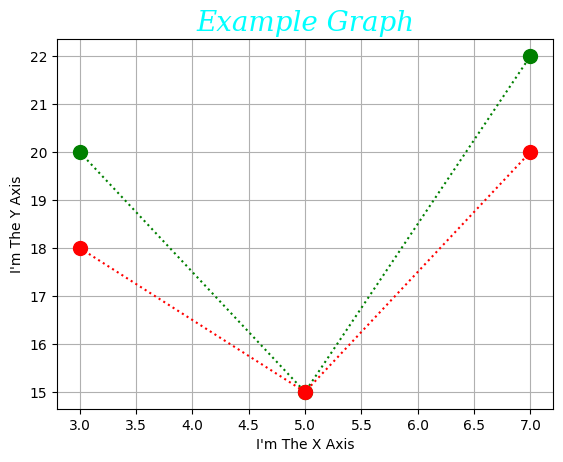

In [22]:
x = np.array([3, 5, 7])
y = np.array([20, 15, 22])
y2 = np.array([18, 15, 20])
plt.plot(x, y, 'o:g', ms=10) # ms changes the size of the marker!
plt.plot(x, y2, 'o:r', ms=10)
plt.grid()
plt.xlabel("I'm The X Axis")
plt.ylabel("I'm The Y Axis")

font1 = {'family':'serif','color':'cyan','size':20, 'fontstyle':'oblique'}
plt.title("Example Graph", fontdict=font1)

We can also show a legend.

Text(0.5, 1.0, 'Example Graph')

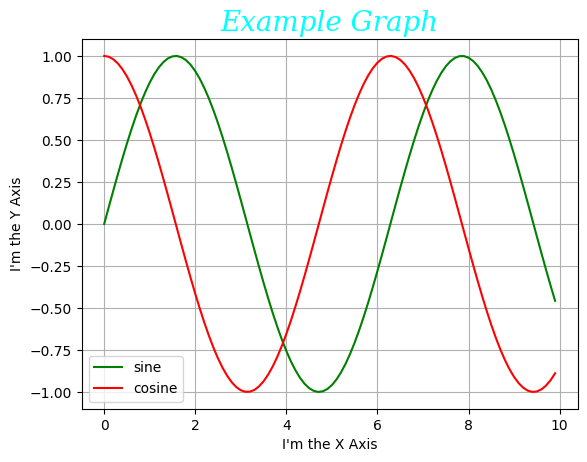

In [23]:
x = np.arange(0, 10, 0.1)
y1 = np.sin(x)
y2 = np.cos(x)
plt.plot(x, y1, "-g", label="sine")
plt.plot(x, y2, "-r", label="cosine")
plt.grid()
plt.legend()
plt.xlabel("I'm the X Axis")
plt.ylabel("I'm the Y Axis")

font1 = {'family':'serif','color':'cyan','size':20, 'fontstyle':'oblique'}
plt.title("Example Graph", fontdict=font1)

## Assignment Section

These question swill be manually graded. The autograder will not be able to grade these questions, but you can still run the code and see the output.

<!-- BEGIN QUESTION -->

**Question 1.**

We will borrow a dataset from Kaggle for this exercise. I have edited it for the purposes of this course.
https://www.kaggle.com/datasets/msjahid/colorado-motor-vehicle-sales-data

For this problem, you will use `pandas` to read the `"data/colorado_motor_vehicle_sales.csv"` file. Then, you will create a histogram of the `sales` column. Use an appropriate number of bins.

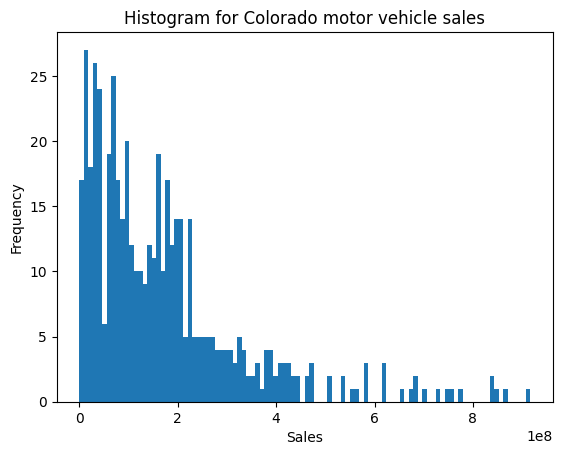

In [25]:
data = pd.read_csv("data/colorado_motor_vehicle_sales.csv")
plt.hist(data['sales'], bins = 100)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Histogram for Colorado motor vehicle sales")
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 2.**

We will borrow a dataset from Kaggle for this exercise. I have edited it for the purposes of this course.
https://www.kaggle.com/datasets/msjahid/colorado-motor-vehicle-sales-data

For this problem, you will use `pandas` to read the `"data/colorado_motor_vehicle_sales.csv"` file. Then, you will create a scatter plot of the `sales` column against the `year` column. Use an appropriate alpha value and color.

Text(0.5, 1.0, 'Scatter plot for sales against year')

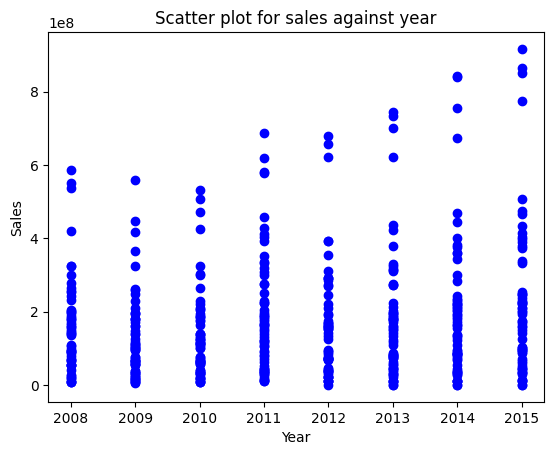

In [28]:
data = pd.read_csv("data/colorado_motor_vehicle_sales.csv")
plt.scatter( data['year'], data['sales'], alpha = 1, c = "blue")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.title("Scatter plot for sales against year")

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 3.**

We will borrow a dataset from Kaggle for this exercise. I have edited it for the purposes of this course.
https://www.kaggle.com/datasets/msjahid/colorado-motor-vehicle-sales-data

For this problem, you will use `pandas` to read the `"data/colorado_motor_vehicle_sales.csv"` file. Then, you will create a line plot of the highest sales for each year. Use an appropriate color and alpha value.

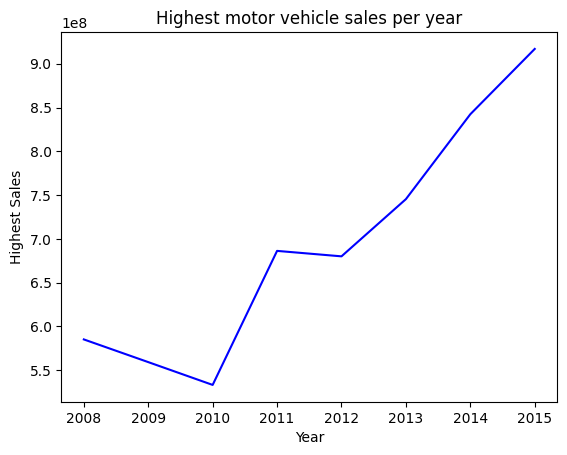

In [32]:
data = pd.read_csv("data/colorado_motor_vehicle_sales.csv")
highest_sales = data.groupby("year")["sales"].max()

plt.plot(highest_sales.index, highest_sales.values,color="blue", alpha=1)
plt.xlabel("Year")
plt.ylabel("Highest Sales")
plt.title("Highest motor vehicle sales per year")

plt.show()


In [30]:
highest_sales

year
2008    585224000.0
2009    559316000.0
2010    533267000.0
2011    686306000.0
2012    680081000.0
2013    745398000.0
2014    842332000.0
2015    916910000.0
Name: sales, dtype: float64

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 4.**

What do you notice about the graphs between Question 3 & 4? Do they look similar? Why or why not?


At a first glance the graphs of Q3 and Q4 might look different. But if we look at the top edge of the Q3 graph for each year and draw imaginary connectig lines it will look similar to Q4. This is expected, because the top edge of the Q3 graph for each year represents the highest sale in that corresponding year. 


<!-- END QUESTION -->

**Question 5.**

Please ignore me :) - I am a free point!

In [33]:
x = 1

In [34]:
grader.check("q5")

q5 results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [35]:
grader.check_all()

q5 results: All test cases passed!